In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
import matplotlib.pyplot as plt
import pandas as pd
import os
from dataclasses import dataclass
from functools import partial

In [2]:
from geom import Interval
from pinn_core import PINN, FCNet
from pde import cylinder_1d
from bc import dirichlet_bc, robin_bc
from analytic import cylinder_1d_robin_exact

In [3]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 16,
})

In [4]:
@dataclass(frozen=True)
class PhysicsParams:
    x_left: float = 0.3
    x_right: float = 0.6
    T_left: float = 300.0
    T_inf: float = 500.0
    _lambda: float = 1.0
    h: float = 10.0

    @property
    def alpha_right(self):
        """Коэффициент при T в условии Робина: α = h"""
        return self.h

    @property
    def beta_right(self):
        """Коэффициент при dT/dx в условии Робина: β = λ"""
        return self._lambda

    @property
    def gamma_right(self):
        """Свободный член в условии Робина: γ = h · T_inf"""
        return self.h * self.T_inf

In [5]:
def get_activation(name):
    mapping = {
        'tanh': nnx.tanh,
        'Swish': nnx.silu,
        'sin': jnp.sin,
        'GELU': nnx.gelu,
        'ReLU': nnx.relu,
        'Sigmoid': nnx.sigmoid,
    }
    return mapping.get(name, nnx.relu)

def get_optimizer(name, lr):
    mapping = {'adam': optax.adam(lr)}
    return mapping.get(name, optax.adam(lr))

In [6]:
def train_model(
    hidden_features, num_layers, activation_name, lr,
    num_points, opt_name, epochs, weights, save_img=False, show_plot=False
):
    phys = PhysicsParams()
    
    geom = Interval(phys.x_left, phys.x_right)
    x_collocation = geom.generate_collocation(n_interior=num_points, method='random')
    total_points = x_collocation.shape[0]

    act_fn = get_activation(activation_name)
    net = FCNet(din=1, dmid=hidden_features, dout=1, num_layers=num_layers, activation=act_fn, rngs=nnx.Rngs(0))
    
    optimizer = get_optimizer(opt_name, lr=lr)
    pinn = PINN(net, opt=optimizer, weights=weights)

    bc_fns = [
        partial(dirichlet_bc, x=phys.x_left, T=phys.T_left),
        partial(robin_bc, x=phys.x_right, alpha=phys.alpha_right, beta=phys.beta_right, h=phys.gamma_right)
    ]

    history, training_time = pinn.fit(
        x_collocation=x_collocation,
        pde_fn=cylinder_1d,
        bc_fns=bc_fns,
        phys=phys,
        epochs=epochs
    )

    x_test = jnp.linspace(phys.x_left, phys.x_right, 100).reshape(-1, 1)
    metrics, T_pred, T_exact = pinn.evaluate(
        x_test, cylinder_1d_robin_exact, phys, bc_names=['dirichlet', 'robin']
    )

    print(f'Эпохи: {epochs}, Время: {training_time:.4f}c, MSE: {metrics['mse']}')

    if save_img:
        pinn.save_plot(x_test, T_pred, T_exact, phys, save_path=f'images/pinn/1D_cylinder_Robin_{epochs}.png')

    if show_plot:
        pinn.show_plot(x_test, T_pred, T_exact, phys)

    result = {
        'bc_left': metrics['bc_left'],
        'bc_right': metrics['bc_right'],
        'training_time': f'{training_time:.4f}',
        'epoches': epochs,
        'lr': lr,
        'activation_func': activation_name,
        'layers': num_layers,
        'neurons': hidden_features,
        'optimizer': opt_name,
        'collocation_points': total_points,
        'mape': metrics['mape'],
        'mae': metrics['mae'],
        'mse': metrics['mse'],
        'rmse': metrics['rmse'],
        'max_error': metrics['max_error'],
        'weights': f'{weights}',
    }

    return result, history

In [7]:
def find_optimal_epochs(
    target_mape, max_epochs, step,
    hidden_features, num_layers,
    activation_name, lr,
    num_points, opt_name,
    weights
):
    for epochs in range(step, max_epochs + 1, step):
        metrics, history = train_model(
            hidden_features, num_layers, activation_name, lr,
            num_points, opt_name, epochs, weights, save_img=False
        )
        if float(metrics['mape']) < target_mape:
            return epochs
    return max_epochs

In [8]:
def try_experiments(eph, lr, csv_path='csv_results/1D_cylinder_robin_results.csv'):
    num_hidden = [32, 64, 128]
    num_layers = [1, 2, 3]
    activation = ['tanh', 'Swish', 'sin', 'GELU', 'ReLU', 'Sigmoid']
    num_interior = [10, 20, 50, 100]
    optimizer = ['adam']
    epochs = [eph]
    weights = [1, 1, 1]
    
    results = []
    exp = 0

    for h in num_hidden:
        for l in num_layers:
            for a in activation:
                for col in num_interior:
                    for opt in optimizer:
                        for epoch in epochs:
                            exp += 1
                            print(f'Experiment {exp}/{len(num_hidden)*len(num_layers)*len(activation)*len(num_interior)}')
                            res, history = train_model(h, l, a, lr, col, opt, epoch, weights)
                            results.append(res)

    df_results = pd.DataFrame(results)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    df_results.to_csv(csv_path, mode='a', header=not os.path.exists(csv_path), index=False)
    print(f'Experiments finished. Results saved to {csv_path}')
    return df_results

In [9]:
# Оптимальные эпохи
learning_rate = 0.01
weights=[1, 1, 1]

optimal_epochs = find_optimal_epochs(
    target_mape=0.001, max_epochs=3000, step=50,
    hidden_features=64, num_layers=2,
    activation_name='GELU', lr=learning_rate,
    num_points=100, opt_name='adam',
    weights=weights
)
optimal_epochs

Эпохи: 50, Время: 1.3276c, MSE: 7.4632e+02
Эпохи: 100, Время: 1.3103c, MSE: 7.3670e+01
Эпохи: 150, Время: 1.1305c, MSE: 1.4340e+02
Эпохи: 200, Время: 1.4196c, MSE: 1.4059e+02
Эпохи: 250, Время: 1.2916c, MSE: 1.2820e+02
Эпохи: 300, Время: 1.3665c, MSE: 1.1618e+02
Эпохи: 350, Время: 1.5080c, MSE: 1.0454e+02
Эпохи: 400, Время: 1.7077c, MSE: 9.3430e+01
Эпохи: 450, Время: 1.6341c, MSE: 8.3001e+01
Эпохи: 500, Время: 1.9063c, MSE: 6.9689e+01
Эпохи: 550, Время: 1.8390c, MSE: 6.3222e+01
Эпохи: 600, Время: 1.6285c, MSE: 5.5439e+01
Эпохи: 650, Время: 1.7434c, MSE: 4.5365e+01
Эпохи: 700, Время: 1.8223c, MSE: 4.0778e+01
Эпохи: 750, Время: 1.9099c, MSE: 3.5169e+01
Эпохи: 800, Время: 1.8574c, MSE: 3.0034e+01
Эпохи: 850, Время: 2.0169c, MSE: 2.4534e+01
Эпохи: 900, Время: 2.4733c, MSE: 2.1132e+01
Эпохи: 950, Время: 2.4677c, MSE: 1.7461e+01
Эпохи: 1000, Время: 2.3041c, MSE: 1.4892e+01
Эпохи: 1050, Время: 2.3282c, MSE: 1.2231e+01
Эпохи: 1100, Время: 2.5267c, MSE: 8.0884e+00
Эпохи: 1150, Время: 2.3180c, M

1750

Эпохи: 1750, Время: 2.4628c, MSE: 1.0811e-01


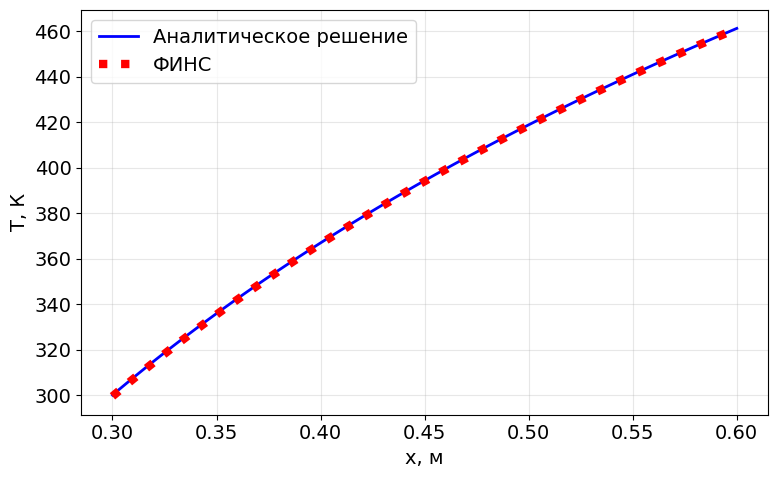

{'bc_left': 'dirichlet',
 'bc_right': 'robin',
 'training_time': '2.4628',
 'epoches': 1750,
 'lr': 0.01,
 'activation_func': 'GELU',
 'layers': 2,
 'neurons': 64,
 'optimizer': 'adam',
 'collocation_points': 102,
 'mape': '8.2738e-04',
 'mae': '3.0133e-01',
 'mse': '1.0811e-01',
 'rmse': '3.2880e-01',
 'max_error': '5.5676e-01',
 'weights': '[1, 1, 1]'}

In [10]:
metrics, history = train_model(
    hidden_features=64, num_layers=2, 
    activation_name='GELU', lr=learning_rate, 
    num_points=100, opt_name='adam', 
    epochs=optimal_epochs, show_plot=True, save_img=True,
    weights=weights
)
metrics

In [11]:
history.keys()

dict_keys(['steps', 'total_loss', 'pde', 'bc_0', 'bc_1'])

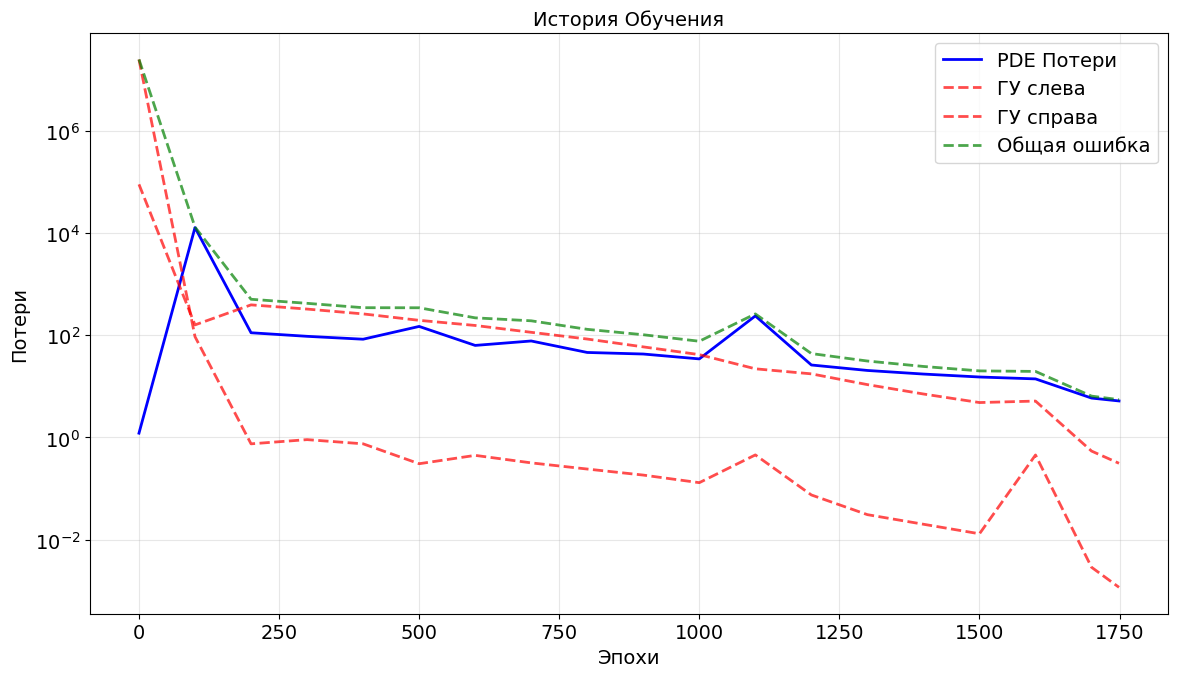

In [12]:
plt.figure(figsize=(12, 7))
steps = history['steps']

plt.semilogy(steps, history['pde'], 'b', label='PDE Потери', linewidth=2) # PDE
plt.semilogy(steps, history['bc_0'], 'r--', label='ГУ слева', linewidth=2, alpha=0.7) # Boundary Conditions
plt.semilogy(steps, history['bc_1'], 'r--', label='ГУ справа', linewidth=2, alpha=0.7)
plt.semilogy(steps, history['total_loss'], 'g--', label='Общая ошибка', linewidth=2, alpha=0.7)

plt.title('История Обучения')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig('images/history_cylinder_robin', dpi=72, bbox_inches='tight')
plt.show()

In [13]:
df_results = try_experiments(optimal_epochs, lr=learning_rate)
df_results.head()

Experiment 1/216
Эпохи: 1750, Время: 0.7755c, MSE: 2.9047e+03
Experiment 2/216
Эпохи: 1750, Время: 1.0293c, MSE: 2.9039e+03
Experiment 3/216
Эпохи: 1750, Время: 0.7779c, MSE: 2.9035e+03
Experiment 4/216
Эпохи: 1750, Время: 1.0374c, MSE: 2.9035e+03
Experiment 5/216
Эпохи: 1750, Время: 0.8099c, MSE: 4.3955e+02
Experiment 6/216
Эпохи: 1750, Время: 0.7566c, MSE: 5.1109e+02
Experiment 7/216
Эпохи: 1750, Время: 0.9243c, MSE: 4.9269e+02
Experiment 8/216
Эпохи: 1750, Время: 0.7531c, MSE: 4.7184e+02
Experiment 9/216
Эпохи: 1750, Время: 0.7365c, MSE: 1.9669e+03
Experiment 10/216
Эпохи: 1750, Время: 0.7919c, MSE: 1.9739e+03
Experiment 11/216
Эпохи: 1750, Время: 0.6231c, MSE: 2.0110e+03
Experiment 12/216
Эпохи: 1750, Время: 0.7268c, MSE: 2.0186e+03
Experiment 13/216
Эпохи: 1750, Время: 1.1022c, MSE: 3.8151e+02
Experiment 14/216
Эпохи: 1750, Время: 0.8539c, MSE: 3.0218e+02
Experiment 15/216
Эпохи: 1750, Время: 1.4360c, MSE: 2.7964e+02
Experiment 16/216
Эпохи: 1750, Время: 1.3403c, MSE: 2.6767e+02
E

,bc_left,bc_right,training_time,epoches,lr,activation_func,layers,neurons,optimizer,collocation_points,mape,mae,mse,rmse,max_error,weights
0,dirichlet,robin,0.7755,1750,0.01,tanh,1,32,adam,12,1.2199e-01,4.3313e+01,2.9047e+03,5.3895e+01,1.1693e+02,"[1.0, 1.0, 1.0]"
1,dirichlet,robin,1.0293,1750,0.01,tanh,1,32,adam,22,1.2198e-01,4.3309e+01,2.9039e+03,5.3888e+01,1.1692e+02,"[1.0, 1.0, 1.0]"
2,dirichlet,robin,0.7779,1750,0.01,tanh,1,32,adam,52,1.2197e-01,4.3306e+01,2.9035e+03,5.3884e+01,1.1691e+02,"[1.0, 1.0, 1.0]"
3,dirichlet,robin,1.0374,1750,0.01,tanh,1,32,adam,102,1.2197e-01,4.3305e+01,2.9035e+03,5.3884e+01,1.1691e+02,"[1.0, 1.0, 1.0]"
4,dirichlet,robin,0.8099,1750,0.01,Swish,1,32,adam,12,5.2577e-02,1.9114e+01,4.3955e+02,2.0965e+01,3.6275e+01,"[1.0, 1.0, 1.0]"
